 <br /><h1 style="font-family:Impact,Arial;font-size:70px;">Project Title TODO</h1>
<h2 style="font-family:Arial;">Group 2</h2>
<h2 style="font-family:Arial;">
<p> * Jensen Jones - 24935900</p>
<p> * Aiden Hemaridis-Smith - TODO</p>
<p> * Matthew Crowe - TODO</p>
</h2>
<p><small> 37373 Programming for Data Analysis</small></p>
<p><small><font color=MediumVioletRed>Autumn 2025</font></small>
</p>
<hr style="height:5px;border:none;color:#333;background-color:#333;" />

 # Abstract

Write a short (no more than 7 lines) summary of your project's topic and main goals.

 This project analyses pedestrian and cyclist transport activity data to identify patterns in movement and potential areas of congestion within urban transport corridors. The dataset contains activity counts collected at multiple locations over time, allowing for detailed analysis of transport demand and usage trends. Python was used to process, clean, and analyse the data efficiently, with visualisations used to communicate key findings. The study aims to determine which locations experience consistently high activity levels and whether these patterns may indicate the need for infrastructure upgrades or improved traffic management strategies. The findings demonstrate how transport activity data can support data-driven urban planning and improve active transport efficiency.

 <hr style="height:5px;border:none;color:#333;background-color:#333;" />
<h1>1. Motivation and Contribution</h1>

Write a detailed description of the problem and the original goal(s) of the study. Explain why you were interested in this topic and the type of insight you were hoping to get from the data.

<b>Explain how your group worked together for this project, and contributions of each member in the group (single line for each group member).</b>

 As cities continue to grow and place more focus on sustainable transport, understanding pedestrian and cyclist movement patterns has become increasingly important. Congestion within active transport corridors can reduce efficiency, accessibility, and overall safety for commuters. As cities continue to encourage active transport methods such as walking and cycling, there is a greater need for infrastructure and traffic management systems that can effectively support demand.

The motivation for this project is to investigate how transport activity data can be used to identify areas experiencing high levels of pedestrian and cyclist congestion. By analysing patterns within the dataset, the project aims to determine whether certain locations may benefit from infrastructure upgrades or adjustments to traffic management systems, such as crossing signal timing or pathway capacity improvements.

This project contributes by applying data analysis techniques to real-world transport activity data and interpreting the findings within the context of urban planning and transport engineering. Rather than simply identifying trends, the study focuses on how the results could be used to support evidence-based decision-making for improving transport efficiency and reducing congestion within active transport networks.

Our group worked together on this project by distributing work evenly amongst each other, as well as taking parts that we as individuals are most interested in:
<P>Jensen: Data Preparation,
<P>Aiden:
<P>Matthew: Abstract, Motivation and Contribution,

TODO ^^

 <hr style="height:5px;border:none;color:#333;background-color:#333;" />
<h1>2. The Data</h1>
A clear description of the dataset(s) origin and a discussion of why it was chosen, as well as any restriction regarding the use, dissemination or modification of the data.

Note that wherever possible you should provide a link to the <b>unmodified, raw</b> data set.


 The dataset used in this project consists of pedestrian and cyclist transport activity count data collected across multiple locations. The data includes information such as count location identifiers, geographical coordinates, activity classifications (pedestrian or cyclist), timestamps, and activity counts recorded within five-minute intervals.

This dataset was selected because it provides a detailed and realistic representation of transport activity within urban environments. The high-frequency recording intervals allow for detailed analysis of peak usage periods and congestion patterns across different locations and times of day. Additionally, the dataset enables comparisons between pedestrian and cyclist activity, providing broader insight into active transport behaviour.

The data is suitable for investigating transport demand and identifying locations that may require improved infrastructure or traffic management strategies. By analysing changes in activity levels over time, the project can identify patterns associated with peak commuting periods and consistently high-demand transport corridors.

However, several limitations exist within the dataset. The data does not include contextual factors such as weather conditions, public events, road closures, or nearby construction activity, all of which may influence transport activity levels. Additionally, the dataset records activity counts only and does not directly measure congestion severity, travel speed, or infrastructure quality. Despite these limitations, the dataset remains appropriate for identifying general transport activity trends and supporting data-driven recommendations.

 <hr style="height:5px;border:none;color:#333;background-color:#333;" />
<h1>3. Data Preparation</h1>

Code and comments on how the raw data is put in a usable form (i.e., how you go from the raw data set(s) to the dataframe you are using for the analysis).

<b>Create as many code, markdown and raw cells as needed</b>

<b>Ensure you use appropriate markdown cells to explain what you are doing and why</b>

 We begin our **data preparation** by downloading the dataset as a zip archive containing 4 CSV files, one per quarter of 2025. Rather than downloading each file manually, we fetch the zip programmatically to keep the notebook self-contained and reproducible. Each file is:

1. Read into its own temporary dataframe
2. Assigned a `quarter` column parsed from the filename, so we retain which quarter each row belongs to after concatenation
3. Appended to `dfs`, our list of quarterly dataframes

Once all four quarters are loaded, they are concatenated into a single dataframe `df` for analysis.

 We include all four quarters to maximise our sample size for more reliable findings, to capture any seasonal variation in transport activity across the year, and to avoid bias that could arise from analysing a single quarter in isolation.

In [1]:
 import pandas as pd

import requests
import io
import zipfile

# This zip contains 4 separate csv files, one per quarter of 2025
# We will concatenate this into one dataframe
url = "https://opendatasoft-s3.s3.ap-southeast-2.amazonaws.com/attachments/TransportActivityCount/TransportActivityCount_2025.zip"

response = requests.get(url)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    dfs = [] # list of each dataframe (each quarter as its own df)
    for name in z.namelist():
        if name.endswith(".csv"):
            print("Reading in file:", name)

            temp = pd.read_csv(z.open(name))
            mainName = name.replace(".csv", "") # without trailing file type
            quarter = mainName.split("-")[-1] # Take just the quarter
            print("\tQuarter:", quarter)
            temp["quarter"] = int(quarter)

            dfs.append(temp)

    df = pd.concat(dfs, ignore_index=True) # concatenate the df's together

Reading in file: TransportActivityCount_2025-3.csv
	Quarter: 3
Reading in file: TransportActivityCount_2025-4.csv
	Quarter: 4
Reading in file: TransportActivityCount_2025-1.csv
	Quarter: 1
Reading in file: TransportActivityCount_2025-2.csv
	Quarter: 2


Part of data preparation includes converting datatypes to a more usable type, as well as handling NA values. First we will check the current status of these conditions in the dataframe:

In [25]:
print(f"Total nulls: {df.isnull().sum().sum()} / {df.size} cells\n")

print(df.dtypes)

Total nulls: 0 / 63942208 cells

countLocationId         int64
countlineName             str
countlineDirection        str
CountLocationLat      float64
CountLocationLong     float64
from                      str
to                        str
class                     str
count                   int64
year                    int64
quarter                 int64
dtype: object


Our dataset is clean and has no null values, we don't have to do anything here.<br>
We will however apply the following type conversions to prepare the data for analysis:
- `from` and `to` are parsed into datetime objects
- `class` and `countlineDirection` are converted to categorical dtype, reducing memory usage and improving groupby performance across the 5.8M row dataset

In [27]:
df["from"] = pd.to_datetime(df["from"])
df["to"] = pd.to_datetime(df["to"])
df["class"] = df["class"].astype("category")
df["countlineDirection"] = df["countlineDirection"].astype("category")

print(df.dtypes)

countLocationId                     int64
countlineName                         str
countlineDirection               category
CountLocationLat                  float64
CountLocationLong                 float64
from                  datetime64[us, UTC]
to                    datetime64[us, UTC]
class                            category
count                               int64
year                                int64
quarter                             int64
dtype: object


 <hr style="height:5px;border:none;color:#333;background-color:#333;" />
<h1>4. Exploratory data analysis</h1>

This is the main part of the project. Include code, plots, and detailed explanation of your analysis of the data. Be sure to include enough detail so that anyone can follow and understand what you are doing.

<b>Create as many code, markdown and raw cells as needed</b>

 ### 4.1 Data Overview & Distributions

Before diving into deeper analysis, we first get a high-level understanding of the dataset's structure and the distribution of its key variables. Here we will look at the distribution of the variable 'class' to get an understanding of the vehicle frequencies, as well as looking into the distribution of records per month throughout 2025.

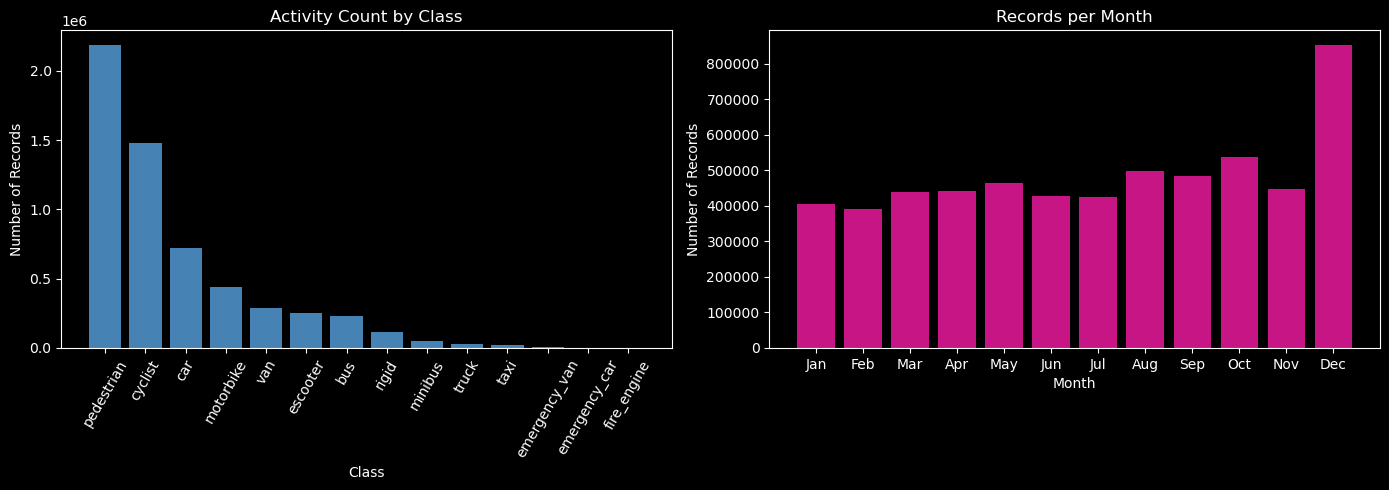

In [32]:
import matplotlib.pyplot as plt
plt.style.use("dark_background") # cooler plots

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
class_counts = df["class"].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color="steelblue")
axes[0].set_title("Activity Count by Class")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Records")
axes[0].tick_params(axis="x", rotation=60)

# Month distribution

month_counts = df["from"].dt.month.value_counts().sort_index()
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
axes[1].bar([month_labels[m-1] for m in month_counts.index], month_counts.values, color="mediumvioletred")
axes[1].set_title("Records per Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Number of Records")

plt.tight_layout()
plt.show()

In [33]:
print(df["class"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%") # percentage of dataset per class type

class
pedestrian       37.55%
cyclist          25.43%
car              12.35%
motorbike         7.54%
van               4.99%
escooter          4.38%
bus               3.91%
rigid             2.03%
minibus           0.81%
truck             0.45%
taxi              0.39%
emergency_van     0.12%
emergency_car     0.03%
fire_engine        0.0%
Name: proportion, dtype: str


The class distribution shows that **pedestrians** and **cyclists** are by far the most recorded activity classes, accounting for ~37.6% and ~25.4% of records respectively. Motor vehicles (cars, motorbikes, vans etc.) make up the remainder, with emergency vehicles and fire engines being relatively rare. This confirms that the dataset is well-suited for active transport analysis.

The monthly distribution is relatively uniform across the year, with **December** standing out as having notably more records than other months. This spike may reflect increased activity during the summer holiday period in Melbourne, or simply more complete sensor coverage in Q4.

### 4.2 Transport Over Time

We now investigate how transport activity varies across time, specifically by hour of day and day of week. This allows us to identify peak demand periods and understand commuting patterns for `pedestrians` and `cyclists`. Given our specific focus on producing usable outcomes for uban planning for `pedestrian` and `cyclists`, we will here group together any vehicle that isn't `pedestrian` or `cyclist` as `other`.

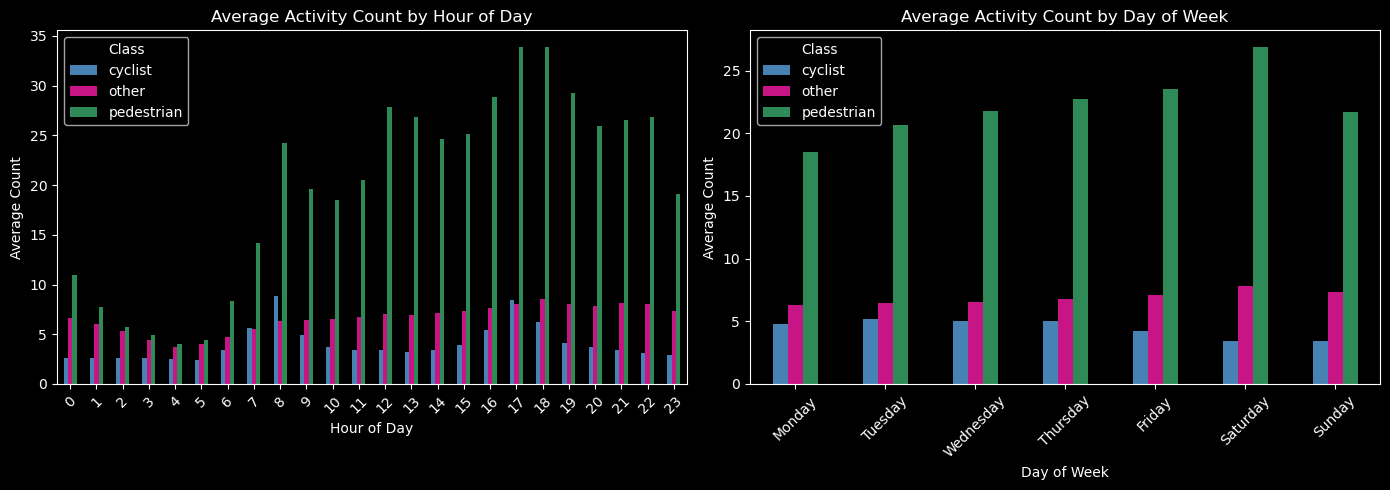

In [37]:
# Classify into three groups
def categorise(classLabel):
    if classLabel == "pedestrian" or classLabel == "cyclist":
        return classLabel
    else:
        return "other"

df["class_group"] = df["class"].map(categorise).astype("category")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["steelblue", "mediumvioletred", "seagreen"]

# Hour of day
hourly = df.groupby([df["from"].dt.hour, "class_group"])["count"].mean().unstack()
hourly.plot(kind="bar", ax=axes[0], color=colors)
axes[0].set_title("Average Activity Count by Hour of Day")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Average Count")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Class")

# Day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["day_of_week"] = df["from"].dt.day_name()
daily = df.groupby(["day_of_week", "class_group"])["count"].mean().unstack()
daily = daily.reindex(day_order)
daily.plot(kind="bar", ax=axes[1], color=colors)
axes[1].set_title("Average Activity Count by Day of Week")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Average Count")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Class")

plt.tight_layout()
plt.show()

The hourly distribution reveals a clear **evening peak for pedestrians at 17:00–18:00**, consistent with end-of-day commuting, with a secondary peak at midday likely reflecting lunch activity. Notably, there is no strong morning commute spike for pedestrians, activity builds gradually from 6am, suggesting these corridors serve a broader mix of trip purposes beyond strict commuting.

Cyclists show a more pronounced **dual peak at 08:00 and 17:00**, strongly consistent with work commute behaviour. This also explains why cyclist counts are relatively low during midday hours compared to other vehicles, which remain steadier throughout the day as cars continue to be used for work-related business regardless of time.

The day-of-week chart reveals an interesting inverse relationship between cyclists and other vehicles on weekends: **cyclist activity drops on Saturday and Sunday while other vehicle activity rises**. Rather than reflecting two distinct groups of people, this may suggest that many commuters are multi-modal — cycling to work on weekdays and switching to driving on weekends. This would explain why the two classes move in opposite directions rather than independently.

Pedestrian activity peaks on **Saturday**, again suggesting these corridors serve a significant recreational function beyond weekday commuting.

 <hr style="height:5px;border:none;color:#333;background-color:#333;" />
<h1>5. Results/Insights</h1>

Discuss any non-trivial result or insight into the problem stemming from your analysis.

<b>Create as many code, markdown and raw cells as needed</b>

 <hr style="height:5px;border:none;color:#333;background-color:#333;" />
<h1>6. In hindsight...</h1>

In this section (no more than 10 lines) you should reflect on your work and what you have learned. In particular you should include:

<ul>
    <li> a discussion of the most challenging aspect of the data analysis and if/how you overcame the challenge.</li>
    <li> a discussion of any programming technique and/or reference you found particularly useful or helpful for your project.</li>
    <li> an assessment of the outcome of the study in relation to the original goals (i.e., have the goals been reached, or did you have to reassess the goals during the project, and if so why?).</li>
    <li> a discussion of what new, or surprising knowledge or insight into the problem you have gained by conducting the study.</li>
    <li> a discussion of whether you would approach the problem differently if given an opportunity to redo the work, and any advice you would give to someone who would want to work on a similar problem.</li>
    <li> a discussion of how your analysis could be improved or extended in future work.</li>

</ul>

In [7]:
TEST

NameError: name 'TEST' is not defined